# 13 Pi0.5 随机位置、coherent recovery 与 EEF-delta

这一节复现四个判断：

1. 为什么逐帧反事实 oracle 标签不能直接拼成 action chunk；
2. 为什么世界坐标 `eef_abs` 会把接近杯子和搬运到盘子两个相反阶段混在一起；
3. 如何用 MuJoCo FK 把原轨迹精确转换成局部 `eef_delta`；
4. 如何把离线 MAE、首帧方向和全新随机种子 strict rollout 放在同一张证据表里。

这里的策略输入只有双相机图像、语言和 6D robot proprio。评估不使用 target/plate 坐标、GT phase、oracle prefix、外置 head 或 scripted finisher。


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "Microsoft YaHei", "DejaVu Sans"]


## 1. Action-chunk DAgger 必须保持时间连续

错误采法让 student action 推进环境，却只在每个 student state 上计算一个没有执行的 oracle 单步标签。每个标签单独看都合理，但相邻标签不属于同一条状态转移链，不能作为 Pi0.5 的未来 50 步动作块。

修正后，Pi0.5 先执行短 prefix，专家从 takeover state 开始真正接管；训练集只保存连续执行的 oracle suffix。失败轨迹单独保留为诊断，不默认混入成功 BC 数据。


In [2]:
dagger_rows = [
    ("反事实逐帧标签", "student", "oracle 未执行", "不能组成未来 action chunk"),
    ("连续专家接管", "oracle", "oracle 连续执行", "可以监督 chunk policy"),
]
pd.DataFrame(dagger_rows, columns=["采集方式", "下一状态执行者", "标签状态", "结论"])


,采集方式,下一状态执行者,标签状态,结论
0,反事实逐帧标签,student,oracle 未执行,不能组成未来 action chunk
1,连续专家接管,oracle,oracle 连续执行,可以监督 chunk policy


## 2. 审计 `eef_abs` 的阶段方向

随机位置完整轨迹中，蓝杯始终在正 Y，盘子始终在负 Y。前段应朝杯子移动，后段则必须转向盘子。若首帧预测直接为负 Y，模型学到的是错误阶段，不是简单的动作噪声。


,区间,absolute action Y 均值 (m)
0,0-20%,0.153594
1,20-40%,0.265544
2,40-60%,0.195898
3,60-80%,-0.093735
4,80-100%,-0.182327


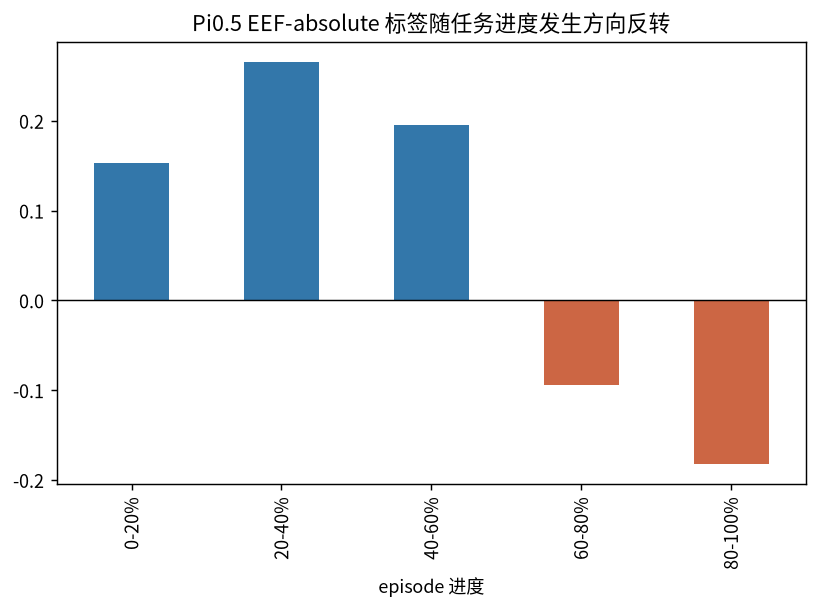

,前80帧朝目标比例,首帧预测为负Y,首帧probe总数,首帧平均Y偏差(m)
0,1.0,6,6,-0.108572


In [3]:
direction = {'episodes': 64, 'frames': 26014, 'target_y_positive_fraction': 1.0, 'plate_y_negative_fraction': 1.0, 'early_toward_target_fraction': 1.0, 'progress_action_y_mean': {'0-20%': 0.15359357784407415, '20-40%': 0.2655442285989148, '40-60%': 0.19589836334684946, '60-80%': -0.09373453054878639, '80-100%': -0.18232691485479655}, 'negative_start_probe_count': 6, 'start_probe_count': 6, 'mean_start_y_bias': -0.10857185496327777}
direction_table = pd.DataFrame({
    '区间': list(direction['progress_action_y_mean']),
    'absolute action Y 均值 (m)': list(direction['progress_action_y_mean'].values()),
})
display(direction_table)
ax = direction_table.plot.bar(x='区间', y='absolute action Y 均值 (m)', legend=False, color=['#3377aa', '#3377aa', '#3377aa', '#cc6644', '#cc6644'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pi0.5 EEF-absolute 标签随任务进度发生方向反转')
ax.set_xlabel('episode 进度')
plt.tight_layout()
plt.show()
pd.DataFrame([{
    '前80帧朝目标比例': direction['early_toward_target_fraction'],
    '首帧预测为负Y': direction['negative_start_probe_count'],
    '首帧probe总数': direction['start_probe_count'],
    '首帧平均Y偏差(m)': direction['mean_start_y_bias'],
}])


## 3. 用当前关节状态做 FK，而不是相邻 action 相减

每帧都有动作执行前的 6D 关节状态 `q_t`。精确转换为：

```text
tcp_t = FK(q_t)
delta_xyz_t = eef_abs_target_xyz_t - tcp_t
```

直接计算 `action[t] - action[t-1]` 会把控制跟踪误差、接触和物理步进误差混入标签。转换后必须重新计算 LeRobot quantile stats，旧的绝对坐标 normalizer 不能复用。


In [4]:
conversion = {'episodes': 64, 'frames': 26014, 'first_action': [0.003999997396022081, 0.004000022076070309, -0.0040000565350055695, 0.0, 0.0, 0.0, 0.0], 'max_spatial_abs': 0.0040756394155323505, 'max_reconstruction_error': 2.3282820116321545e-10, 'source_probe_hashes_unchanged': True, 'has_quantile_stats': True}
pd.DataFrame([conversion])


,episodes,frames,first_action,max_spatial_abs,max_reconstruction_error,source_probe_hashes_unchanged,has_quantile_stats
0,64,26014,"[0.003999997396022081, 0.004000022076070309, -...",0.004076,2.328282e-10,True,True


In [5]:
print(r'''export PROJECT_ROOT=/path/to/04mujoco复现ACT、Pi0、SmolVLA
export TOPIC_ROOT=/path/to/every-embodied/16-专题组队学习/04-AMD-ROCm策略复刻专题
export ABS_ROOT=/path/to/lerobot_eef_abs_v30
export DELTA_ROOT=/path/to/lerobot_eef_delta_v30

cd "$PROJECT_ROOT"
DISPLAY="${DISPLAY:-:0}" PYTHONPATH="$PROJECT_ROOT:${PYTHONPATH:-}" python "$TOPIC_ROOT/code/pi0/pi05_convert_eef_abs_to_delta.py"   --source-root "$ABS_ROOT"   --output-root "$DELTA_ROOT"   --repo-id datawhale_eai_pnp_pi05_eef_delta_v30   --scene "$PROJECT_ROOT/asset/example_scene_y2.xml"''')


export PROJECT_ROOT=/path/to/04mujoco复现ACT、Pi0、SmolVLA
export TOPIC_ROOT=/path/to/every-embodied/16-专题组队学习/04-AMD-ROCm策略复刻专题
export ABS_ROOT=/path/to/lerobot_eef_abs_v30
export DELTA_ROOT=/path/to/lerobot_eef_delta_v30

cd "$PROJECT_ROOT"
DISPLAY="${DISPLAY:-:0}" PYTHONPATH="$PROJECT_ROOT:${PYTHONPATH:-}" python "$TOPIC_ROOT/code/pi0/pi05_convert_eef_abs_to_delta.py"   --source-root "$ABS_ROOT"   --output-root "$DELTA_ROOT"   --repo-id datawhale_eai_pnp_pi05_eef_delta_v30   --scene "$PROJECT_ROOT/asset/example_scene_y2.xml"


## 4. 训练结果先看首帧方向，再看 closed-loop

`eef_abs` 和 `eef_delta` 语义不同，delta 分支必须从官方 Pi0.5 基座重新适配 action expert。训练日志还应确认 strict 权重加载、action head 确实更新、冻结 VLM 的参数变化为 0。


,step,loss,loss_window_mean,learning_rate,grad_norm,memory_peak_gib
71,710,0.236005,0.441694,3.511176e-07,3.969491,11.142135
72,720,0.383331,0.436856,2.781181e-07,2.439316,11.142135
73,730,0.323361,0.414101,2.134025e-07,3.009227,11.142135
74,740,0.241016,0.371807,1.570842e-07,3.651368,11.142135
75,750,0.289641,0.420056,1.092620e-07,2.682659,11.142135
76,760,1.074834,0.514304,7.001981e-08,15.589719,11.142135
77,770,0.436091,0.379699,3.942649e-08,2.827284,11.142135
78,780,0.380316,0.419703,1.753570e-08,3.039821,11.142135
79,790,0.395599,0.404411,4.385850e-09,2.863014,11.142135
80,800,0.181156,0.356420,0.000000e+00,3.997414,11.142135


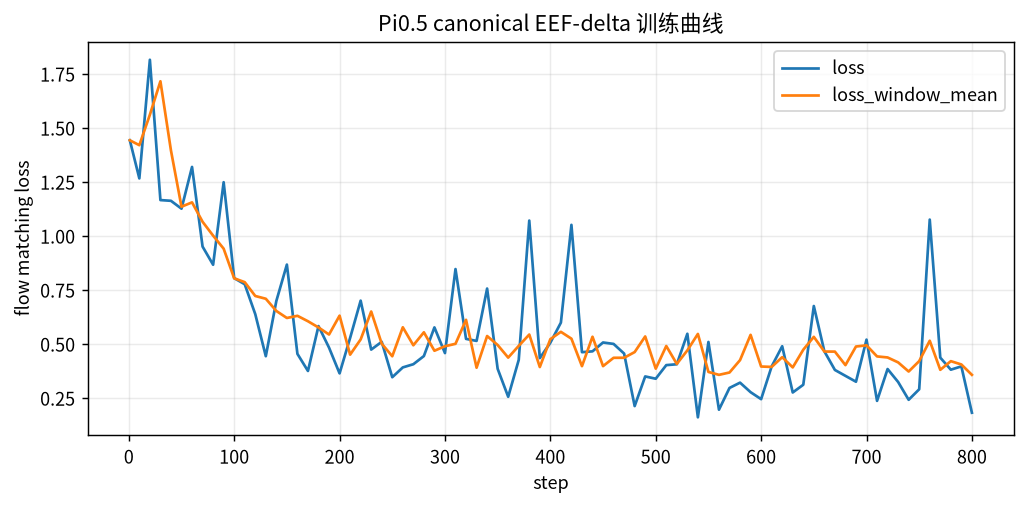

In [6]:
training = {'base': 'official lerobot/pi05_base', 'dataset': 'canonical91 EEF-delta', 'steps': 800, 'chunk_size': 10, 'batch_size': 4, 'learning_rate': 1e-05, 'action_loss_weights': [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 2.0], 'trainable_parameters': 430098464, 'trainable_head_max_delta': 0.0005358410999178886, 'frozen_vlm_max_delta': 0.0, 'memory_peak_gib': 11.14213514328003, 'dataset_alignment': {'status': 'passed', 'frames': 35284, 'episodes': 91, 'physical_index_mismatch_rows': 0, 'chunk0_probes': 273, 'chunk0_max_abs_error': 0.0}, 'current_observations_sampled': 3200, 'frame_equivalent_fraction': 0.09069266523069947, 'baseline': {'flow_loss_mean': 1.8661300887664158, 'action_mae': 0.07254758477210999, 'xyz_mae': 0.0030045867897570133, 'gripper_mae': 0.4988192915916443, 'valid_action_rows': 240}, 'final': {'flow_loss_mean': 0.7276507802307606, 'action_mae': 0.045883774757385254, 'xyz_mae': 0.0023318433668464422, 'gripper_mae': 0.3141908645629883, 'valid_action_rows': 240}, 'curve': [{'step': 1, 'loss': 1.4417556524276733, 'loss_window_mean': 1.4417556524276733, 'learning_rate': 2.0000000000000002e-07, 'grad_norm': 17.92433738708496, 'memory_peak_gib': 11.13605785369873}, {'step': 10, 'loss': 1.2654118537902832, 'loss_window_mean': 1.4192016005516053, 'learning_rate': 2e-06, 'grad_norm': 10.447264671325684, 'memory_peak_gib': 11.14213514328003}, {'step': 20, 'loss': 1.8144220113754272, 'loss_window_mean': 1.5600367546081544, 'learning_rate': 4e-06, 'grad_norm': 22.87356185913086, 'memory_peak_gib': 11.14213514328003}, {'step': 30, 'loss': 1.165132761001587, 'loss_window_mean': 1.714900255203247, 'learning_rate': 6e-06, 'grad_norm': 6.110684394836426, 'memory_peak_gib': 11.14213514328003}, {'step': 40, 'loss': 1.1618106365203857, 'loss_window_mean': 1.394715392589569, 'learning_rate': 8e-06, 'grad_norm': 10.046595573425293, 'memory_peak_gib': 11.14213514328003}, {'step': 50, 'loss': 1.1253511905670166, 'loss_window_mean': 1.134506142139435, 'learning_rate': 1e-05, 'grad_norm': 4.444893836975098, 'memory_peak_gib': 11.14213514328003}, {'step': 60, 'loss': 1.3185391426086426, 'loss_window_mean': 1.154559999704361, 'learning_rate': 9.995614150494293e-06, 'grad_norm': 5.843959808349609, 'memory_peak_gib': 11.14213514328003}, {'step': 70, 'loss': 0.950001060962677, 'loss_window_mean': 1.0648394346237182, 'learning_rate': 9.982464296247523e-06, 'grad_norm': 5.329283714294434, 'memory_peak_gib': 11.14213514328003}, {'step': 80, 'loss': 0.8659399747848511, 'loss_window_mean': 1.0005968928337097, 'learning_rate': 9.960573506572391e-06, 'grad_norm': 4.88935661315918, 'memory_peak_gib': 11.14213514328003}, {'step': 90, 'loss': 1.247843861579895, 'loss_window_mean': 0.9402445971965789, 'learning_rate': 9.929980185352525e-06, 'grad_norm': 6.4207305908203125, 'memory_peak_gib': 11.14213514328003}, {'step': 100, 'loss': 0.8038835525512695, 'loss_window_mean': 0.8031426101922989, 'learning_rate': 9.890738003669029e-06, 'grad_norm': 5.595571041107178, 'memory_peak_gib': 11.14213514328003}, {'step': 110, 'loss': 0.7756472826004028, 'loss_window_mean': 0.7853406429290771, 'learning_rate': 9.842915805643156e-06, 'grad_norm': 5.915187835693359, 'memory_peak_gib': 11.14213514328003}, {'step': 120, 'loss': 0.6373303532600403, 'loss_window_mean': 0.7213600903749466, 'learning_rate': 9.786597487660336e-06, 'grad_norm': 6.097359657287598, 'memory_peak_gib': 11.14213514328003}, {'step': 130, 'loss': 0.44265979528427124, 'loss_window_mean': 0.7085215389728546, 'learning_rate': 9.721881851187406e-06, 'grad_norm': 3.655480146408081, 'memory_peak_gib': 11.14213514328003}, {'step': 140, 'loss': 0.6982430815696716, 'loss_window_mean': 0.6520547837018966, 'learning_rate': 9.648882429441258e-06, 'grad_norm': 4.649959564208984, 'memory_peak_gib': 11.14213514328003}, {'step': 150, 'loss': 0.8665914535522461, 'loss_window_mean': 0.6195504486560821, 'learning_rate': 9.567727288213005e-06, 'grad_norm': 5.1642584800720215, 'memory_peak_gib': 11.14213514328003}, {'step': 160, 'loss': 0.4535171091556549, 'loss_window_mean': 0.629642778635025, 'learning_rate': 9.478558801197065e-06, 'grad_norm': 3.602992057800293, 'memory_peak_gib': 11.14213514328003}, {'step': 170, 'loss': 0.3743523955345154, 'loss_window_mean': 0.6044069200754165, 'learning_rate': 9.381533400219319e-06, 'grad_norm': 3.9225196838378906, 'memory_peak_gib': 11.14213514328003}, {'step': 180, 'loss': 0.582123339176178, 'loss_window_mean': 0.5756960898637772, 'learning_rate': 9.276821300802535e-06, 'grad_norm': 5.6062331199646, 'memory_peak_gib': 11.14213514328003}, {'step': 190, 'loss': 0.48226675391197205, 'loss_window_mean': 0.5429364055395126, 'learning_rate': 9.164606203550498e-06, 'grad_norm': 4.538710594177246, 'memory_peak_gib': 11.14213514328003}, {'step': 200, 'loss': 0.36315223574638367, 'loss_window_mean': 0.6303666234016418, 'learning_rate': 9.045084971874738e-06, 'grad_norm': 3.1310110092163086, 'memory_peak_gib': 11.14213514328003}, {'step': 210, 'loss': 0.5272535681724548, 'loss_window_mean': 0.44980175644159315, 'learning_rate': 8.9184672866292e-06, 'grad_norm': 2.7016584873199463, 'memory_peak_gib': 11.14213514328003}, {'step': 220, 'loss': 0.6997479796409607, 'loss_window_mean': 0.5202830523252487, 'learning_rate': 8.784975278258783e-06, 'grad_norm': 3.6506481170654297, 'memory_peak_gib': 11.14213514328003}, {'step': 230, 'loss': 0.473248153924942, 'loss_window_mean': 0.6495455771684646, 'learning_rate': 8.644843137107058e-06, 'grad_norm': 4.24538516998291, 'memory_peak_gib': 11.14213514328003}, {'step': 240, 'loss': 0.5092160701751709, 'loss_window_mean': 0.5006179541349411, 'learning_rate': 8.498316702566828e-06, 'grad_norm': 3.5401418209075928, 'memory_peak_gib': 11.14213514328003}, {'step': 250, 'loss': 0.34540748596191406, 'loss_window_mean': 0.442427733540535, 'learning_rate': 8.345653031794292e-06, 'grad_norm': 4.2529616355896, 'memory_peak_gib': 11.14213514328003}, {'step': 260, 'loss': 0.3908185660839081, 'loss_window_mean': 0.5765176087617874, 'learning_rate': 8.18711994874345e-06, 'grad_norm': 3.1925251483917236, 'memory_peak_gib': 11.14213514328003}, {'step': 270, 'loss': 0.40556472539901733, 'loss_window_mean': 0.49329228699207306, 'learning_rate': 8.022995574311876e-06, 'grad_norm': 5.005031108856201, 'memory_peak_gib': 11.14213514328003}, {'step': 280, 'loss': 0.44332557916641235, 'loss_window_mean': 0.5532789498567581, 'learning_rate': 7.85356783842216e-06, 'grad_norm': 4.756326198577881, 'memory_peak_gib': 11.14213514328003}, {'step': 290, 'loss': 0.5760244727134705, 'loss_window_mean': 0.4679155319929123, 'learning_rate': 7.679133974894984e-06, 'grad_norm': 4.0674638748168945, 'memory_peak_gib': 11.14213514328003}, {'step': 300, 'loss': 0.45710864663124084, 'loss_window_mean': 0.48870720267295836, 'learning_rate': 7.500000000000001e-06, 'grad_norm': 3.8178486824035645, 'memory_peak_gib': 11.14213514328003}, {'step': 310, 'loss': 0.8459497690200806, 'loss_window_mean': 0.5000417187809945, 'learning_rate': 7.31648017559931e-06, 'grad_norm': 8.430974006652832, 'memory_peak_gib': 11.14213514328003}, {'step': 320, 'loss': 0.5228030681610107, 'loss_window_mean': 0.6109683305025101, 'learning_rate': 7.128896457825364e-06, 'grad_norm': 6.358067512512207, 'memory_peak_gib': 11.14213514328003}, {'step': 330, 'loss': 0.5134061574935913, 'loss_window_mean': 0.3894116789102554, 'learning_rate': 6.9375779322605154e-06, 'grad_norm': 5.882976531982422, 'memory_peak_gib': 11.14213514328003}, {'step': 340, 'loss': 0.7557446956634521, 'loss_window_mean': 0.53605537712574, 'learning_rate': 6.7428602366090764e-06, 'grad_norm': 10.347887992858887, 'memory_peak_gib': 11.14213514328003}, {'step': 350, 'loss': 0.38439640402793884, 'loss_window_mean': 0.494500470161438, 'learning_rate': 6.545084971874738e-06, 'grad_norm': 3.290647506713867, 'memory_peak_gib': 11.14213514328003}, {'step': 360, 'loss': 0.25496339797973633, 'loss_window_mean': 0.4361968904733658, 'learning_rate': 6.344599103076329e-06, 'grad_norm': 2.3100244998931885, 'memory_peak_gib': 11.14213514328003}, {'step': 370, 'loss': 0.4255277216434479, 'loss_window_mean': 0.4905035555362701, 'learning_rate': 6.141754350553279e-06, 'grad_norm': 3.3459222316741943, 'memory_peak_gib': 11.14213514328003}, {'step': 380, 'loss': 1.0703399181365967, 'loss_window_mean': 0.542897954583168, 'learning_rate': 5.936906572928625e-06, 'grad_norm': 12.507841110229492, 'memory_peak_gib': 11.14213514328003}, {'step': 390, 'loss': 0.43372321128845215, 'loss_window_mean': 0.39251488745212554, 'learning_rate': 5.730415142812059e-06, 'grad_norm': 3.360889434814453, 'memory_peak_gib': 11.14213514328003}, {'step': 400, 'loss': 0.5051335692405701, 'loss_window_mean': 0.5216175526380539, 'learning_rate': 5.522642316338268e-06, 'grad_norm': 6.198289394378662, 'memory_peak_gib': 11.14213514328003}, {'step': 410, 'loss': 0.5980904698371887, 'loss_window_mean': 0.5554435983300209, 'learning_rate': 5.3139525976465675e-06, 'grad_norm': 4.662997245788574, 'memory_peak_gib': 11.14213514328003}, {'step': 420, 'loss': 1.0505011081695557, 'loss_window_mean': 0.5237489521503449, 'learning_rate': 5.1047120994167855e-06, 'grad_norm': 9.173433303833008, 'memory_peak_gib': 11.14213514328003}, {'step': 430, 'loss': 0.461292028427124, 'loss_window_mean': 0.39654761999845506, 'learning_rate': 4.895287900583216e-06, 'grad_norm': 3.7262845039367676, 'memory_peak_gib': 11.14213514328003}, {'step': 440, 'loss': 0.4652067720890045, 'loss_window_mean': 0.5328009217977524, 'learning_rate': 4.686047402353433e-06, 'grad_norm': 10.385488510131836, 'memory_peak_gib': 11.14213514328003}, {'step': 450, 'loss': 0.5061522722244263, 'loss_window_mean': 0.3967305332422256, 'learning_rate': 4.477357683661734e-06, 'grad_norm': 3.6560938358306885, 'memory_peak_gib': 11.14213514328003}, {'step': 460, 'loss': 0.49948805570602417, 'loss_window_mean': 0.43527990877628325, 'learning_rate': 4.269584857187942e-06, 'grad_norm': 3.402996778488159, 'memory_peak_gib': 11.14213514328003}, {'step': 470, 'loss': 0.4548255503177643, 'loss_window_mean': 0.43546119928359983, 'learning_rate': 4.063093427071376e-06, 'grad_norm': 2.596640110015869, 'memory_peak_gib': 11.14213514328003}, {'step': 480, 'loss': 0.21186473965644836, 'loss_window_mean': 0.4617734611034393, 'learning_rate': 3.8582456494467214e-06, 'grad_norm': 1.7170941829681396, 'memory_peak_gib': 11.14213514328003}, {'step': 490, 'loss': 0.34907472133636475, 'loss_window_mean': 0.5340840175747872, 'learning_rate': 3.655400896923672e-06, 'grad_norm': 9.269362449645996, 'memory_peak_gib': 11.14213514328003}, {'step': 500, 'loss': 0.3384384214878082, 'loss_window_mean': 0.3850263386964798, 'learning_rate': 3.4549150281252635e-06, 'grad_norm': 2.6124203205108643, 'memory_peak_gib': 11.14213514328003}, {'step': 510, 'loss': 0.4014032483100891, 'loss_window_mean': 0.4897883325815201, 'learning_rate': 3.2571397633909252e-06, 'grad_norm': 4.532131671905518, 'memory_peak_gib': 11.14213514328003}, {'step': 520, 'loss': 0.4053635001182556, 'loss_window_mean': 0.40699050575494766, 'learning_rate': 3.0624220677394854e-06, 'grad_norm': 2.9826910495758057, 'memory_peak_gib': 11.14213514328003}, {'step': 530, 'loss': 0.5464410185813904, 'loss_window_mean': 0.4697120666503906, 'learning_rate': 2.871103542174637e-06, 'grad_norm': 7.868485450744629, 'memory_peak_gib': 11.14213514328003}, {'step': 540, 'loss': 0.1598701775074005, 'loss_window_mean': 0.5457518607378006, 'learning_rate': 2.683519824400693e-06, 'grad_norm': 2.382927894592285, 'memory_peak_gib': 11.14213514328003}, {'step': 550, 'loss': 0.5085831880569458, 'loss_window_mean': 0.36985157430171967, 'learning_rate': 2.5000000000000015e-06, 'grad_norm': 3.4796156883239746, 'memory_peak_gib': 11.14213514328003}, {'step': 560, 'loss': 0.1951654851436615, 'loss_window_mean': 0.35639636814594267, 'learning_rate': 2.320866025105016e-06, 'grad_norm': 1.9940476417541504, 'memory_peak_gib': 11.14213514328003}, {'step': 570, 'loss': 0.2957967519760132, 'loss_window_mean': 0.3672603234648705, 'learning_rate': 2.146432161577842e-06, 'grad_norm': 3.245014190673828, 'memory_peak_gib': 11.14213514328003}, {'step': 580, 'loss': 0.3202844262123108, 'loss_window_mean': 0.4245576798915863, 'learning_rate': 1.977004425688126e-06, 'grad_norm': 2.6708970069885254, 'memory_peak_gib': 11.14213514328003}, {'step': 590, 'loss': 0.2762383818626404, 'loss_window_mean': 0.541545957326889, 'learning_rate': 1.8128800512565514e-06, 'grad_norm': 2.283701181411743, 'memory_peak_gib': 11.14213514328003}, {'step': 600, 'loss': 0.2439223974943161, 'loss_window_mean': 0.39494886845350263, 'learning_rate': 1.6543469682057105e-06, 'grad_norm': 2.3808577060699463, 'memory_peak_gib': 11.14213514328003}, {'step': 610, 'loss': 0.39529117941856384, 'loss_window_mean': 0.39307540059089663, 'learning_rate': 1.5016832974331725e-06, 'grad_norm': 12.575508117675781, 'memory_peak_gib': 11.14213514328003}, {'step': 620, 'loss': 0.48883605003356934, 'loss_window_mean': 0.4381705656647682, 'learning_rate': 1.3551568628929434e-06, 'grad_norm': 3.0441272258758545, 'memory_peak_gib': 11.14213514328003}, {'step': 630, 'loss': 0.27479487657546997, 'loss_window_mean': 0.3908743917942047, 'learning_rate': 1.2150247217412186e-06, 'grad_norm': 2.226179838180542, 'memory_peak_gib': 11.14213514328003}, {'step': 640, 'loss': 0.3105739951133728, 'loss_window_mean': 0.4727252021431923, 'learning_rate': 1.0815327133708015e-06, 'grad_norm': 1.8943754434585571, 'memory_peak_gib': 11.14213514328003}, {'step': 650, 'loss': 0.6749321818351746, 'loss_window_mean': 0.5321788474917412, 'learning_rate': 9.549150281252633e-07, 'grad_norm': 6.666606903076172, 'memory_peak_gib': 11.14213514328003}, {'step': 660, 'loss': 0.4653055667877197, 'loss_window_mean': 0.464268296957016, 'learning_rate': 8.353937964495029e-07, 'grad_norm': 3.4764044284820557, 'memory_peak_gib': 11.14213514328003}, {'step': 670, 'loss': 0.37903326749801636, 'loss_window_mean': 0.4639122486114502, 'learning_rate': 7.23178699197467e-07, 'grad_norm': 3.6408205032348633, 'memory_peak_gib': 11.14213514328003}, {'step': 680, 'loss': 0.3517443835735321, 'loss_window_mean': 0.4014388144016266, 'learning_rate': 6.184665997806832e-07, 'grad_norm': 2.1739017963409424, 'memory_peak_gib': 11.14213514328003}, {'step': 690, 'loss': 0.3245919346809387, 'loss_window_mean': 0.48749532252550126, 'learning_rate': 5.214411988029355e-07, 'grad_norm': 2.402776002883911, 'memory_peak_gib': 11.14213514328003}, {'step': 700, 'loss': 0.5193167924880981, 'loss_window_mean': 0.492905730009079, 'learning_rate': 4.322727117869951e-07, 'grad_norm': 2.9502995014190674, 'memory_peak_gib': 11.14213514328003}, {'step': 710, 'loss': 0.23600494861602783, 'loss_window_mean': 0.4416937083005905, 'learning_rate': 3.511175705587433e-07, 'grad_norm': 3.9694910049438477, 'memory_peak_gib': 11.14213514328003}, {'step': 720, 'loss': 0.3833305835723877, 'loss_window_mean': 0.4368560403585434, 'learning_rate': 2.7811814881259503e-07, 'grad_norm': 2.4393162727355957, 'memory_peak_gib': 11.14213514328003}, {'step': 730, 'loss': 0.3233606219291687, 'loss_window_mean': 0.41410118341445923, 'learning_rate': 2.134025123396638e-07, 'grad_norm': 3.0092265605926514, 'memory_peak_gib': 11.14213514328003}, {'step': 740, 'loss': 0.2410159409046173, 'loss_window_mean': 0.3718071937561035, 'learning_rate': 1.5708419435684463e-07, 'grad_norm': 3.6513679027557373, 'memory_peak_gib': 11.14213514328003}, {'step': 750, 'loss': 0.2896406650543213, 'loss_window_mean': 0.42005575597286227, 'learning_rate': 1.0926199633097156e-07, 'grad_norm': 2.682659149169922, 'memory_peak_gib': 11.14213514328003}, {'step': 760, 'loss': 1.074833631515503, 'loss_window_mean': 0.5143037632107734, 'learning_rate': 7.001981464747565e-08, 'grad_norm': 15.58971881866455, 'memory_peak_gib': 11.14213514328003}, {'step': 770, 'loss': 0.43609103560447693, 'loss_window_mean': 0.37969904989004133, 'learning_rate': 3.9426493427611177e-08, 'grad_norm': 2.8272836208343506, 'memory_peak_gib': 11.14213514328003}, {'step': 780, 'loss': 0.38031595945358276, 'loss_window_mean': 0.41970276534557344, 'learning_rate': 1.753570375247815e-08, 'grad_norm': 3.039820671081543, 'memory_peak_gib': 11.14213514328003}, {'step': 790, 'loss': 0.3955989181995392, 'loss_window_mean': 0.40441102385520933, 'learning_rate': 4.385849505708084e-09, 'grad_norm': 2.863013744354248, 'memory_peak_gib': 11.14213514328003}, {'step': 800, 'loss': 0.18115566670894623, 'loss_window_mean': 0.3564197301864624, 'learning_rate': 0.0, 'grad_norm': 3.9974138736724854, 'memory_peak_gib': 11.14213514328003}]}
pd.DataFrame([
    {'阶段': '训练前', **training['baseline']},
    {'阶段': '训练后', **training['final']},
])
curve = pd.DataFrame(training.get('curve', []))
if not curve.empty:
    display(curve.tail(10))
    ax = curve.plot(x='step', y=['loss', 'loss_window_mean'], figsize=(8, 4))
    ax.set_title('Pi0.5 canonical EEF-delta 训练曲线')
    ax.set_ylabel('flow matching loss')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 5. 全新随机种子 strict fair-VLA

离线误差只能说明训练健康。最终仍使用 lift、upright、plate height、plate displacement 和 stable-place 五组物理条件，并保存四视角视频复核。


In [7]:
evaluation = {'episodes': 4, 'physical_success_count': 0, 'physical_success_rate': 0.0, 'legacy_success_count': 0, 'legacy_success_rate': 0.0, 'seeds': [2180, 2181, 2182, 2183], 'position_profile': 'pnp_generalization_v1', 'fair_vla': True, 'action_mode': 'eef_delta', 'execution_horizon': 10, 'fresh_env_per_episode': True, 'hard_reset_sim_data': True, 'physics_steps_per_action': 25}
training_seed_evaluation = {'episodes': 4, 'physical_success_count': 0, 'physical_success_rate': 0.0, 'legacy_success_count': 0, 'legacy_success_rate': 0.0, 'seeds': [1000, 1001, 1002, 1003], 'position_profile': 'pnp_generalization_v1', 'fair_vla': True, 'action_mode': 'eef_delta', 'execution_horizon': 10, 'fresh_env_per_episode': True, 'hard_reset_sim_data': True, 'physics_steps_per_action': 25}
summary_fields = ['episodes', 'physical_success_count', 'physical_success_rate', 'legacy_success_count', 'legacy_success_rate', 'execution_horizon']
rows = [
    {'评估面板': '全新随机种子', **{key: evaluation[key] for key in summary_fields}},
]
if training_seed_evaluation:
    rows.insert(0, {'评估面板': '训练内种子', **{key: training_seed_evaluation[key] for key in summary_fields}})
pd.DataFrame(rows)


,评估面板,episodes,physical_success_count,physical_success_rate,legacy_success_count,legacy_success_rate,execution_horizon
0,训练内种子,4,0,0.0,0,0.0,10
1,全新随机种子,4,0,0.0,0,0.0,10


训练内 seed 和全新 seed 同时失败时，先检查是否真正覆盖过足够多的当前观测。这里的 `step × batch_size` 只是抽样次数；加权采样还会重复起步、尾段和夹爪切换窗口，不能把一次 action chunk 里的 10 个未来动作误算成 10 个独立视觉状态。


In [8]:
pd.DataFrame([{
    '训练step': training['steps'],
    'batch size': training['batch_size'],
    '当前观测抽样次数': training['current_observations_sampled'],
    '相对全数据帧数': training['frame_equivalent_fraction'],
}])


,训练step,batch size,当前观测抽样次数,相对全数据帧数
0,800,4,3200,0.090693


## 6. 从逐步轨迹定位“靠近之后发生了什么”

`0/4` 仍然太粗。逐步日志要回答三个问题：TCP 最接近杯子时有多远、当时比杯体高多少、夹爪是否已经闭合。若 TCP 先在高处闭合，再继续平移，最后才在杯子外下降，就属于阶段顺序错误，不是“完全没有识别杯子”。


In [9]:
phase_diagnostics = [{'seed': 2180, 'nearest_logged_step': 155, 'nearest_tcp_target_xy_m': 0.054835207668066696, 'tcp_target_z_gap_at_nearest_m': 0.1271, 'gripper_at_nearest': 0.02619794015488298, 'lowest_logged_step': 360, 'lowest_tcp_target_z_gap_m': -0.03839999999999999, 'tcp_target_xy_at_lowest_m': 0.34268009863428023, 'max_target_lift_m': 1.2853031164938855e-06}, {'seed': 2181, 'nearest_logged_step': 75, 'nearest_tcp_target_xy_m': 0.05399351812949405, 'tcp_target_z_gap_at_nearest_m': 0.1381, 'gripper_at_nearest': 0.020328813205147046, 'lowest_logged_step': 225, 'lowest_tcp_target_z_gap_m': -0.03810000000000002, 'tcp_target_xy_at_lowest_m': 0.29298071608896037, 'max_target_lift_m': 1.2855770460395988e-06}, {'seed': 2182, 'nearest_logged_step': 105, 'nearest_tcp_target_xy_m': 0.06663249957790868, 'tcp_target_z_gap_at_nearest_m': 0.10819999999999996, 'gripper_at_nearest': 0.009426771461153876, 'lowest_logged_step': 215, 'lowest_tcp_target_z_gap_m': -0.03749999999999998, 'tcp_target_xy_at_lowest_m': 0.25280031645549816, 'max_target_lift_m': 2.7370485115030263e-06}, {'seed': 2183, 'nearest_logged_step': 125, 'nearest_tcp_target_xy_m': 0.0540268451790404, 'tcp_target_z_gap_at_nearest_m': 0.10409999999999997, 'gripper_at_nearest': -0.0007415589700601158, 'lowest_logged_step': 400, 'lowest_tcp_target_z_gap_m': -0.03820000000000001, 'tcp_target_xy_at_lowest_m': 0.2462196174150224, 'max_target_lift_m': 0.001621553991664193}]
pd.DataFrame(phase_diagnostics)


,seed,nearest_logged_step,nearest_tcp_target_xy_m,tcp_target_z_gap_at_nearest_m,gripper_at_nearest,lowest_logged_step,lowest_tcp_target_z_gap_m,tcp_target_xy_at_lowest_m,max_target_lift_m
0,2180,155,0.054835,0.1271,0.026198,360,-0.0384,0.342680,0.000001
1,2181,75,0.053994,0.1381,0.020329,225,-0.0381,0.292981,0.000001
2,2182,105,0.066632,0.1082,0.009427,215,-0.0375,0.252800,0.000003
3,2183,125,0.054027,0.1041,-0.000742,400,-0.0382,0.246220,0.001622


![Pi0.5 canonical91 训练内 seed1003 失败序列](../assets/pi05_canonical_s800_seed1003_montage.png)

图中策略先向蓝杯靠近，夹爪在杯子上方/侧方闭合，随后将杯子推倒并继续越过目标。这个视频是 raw Pi0.5 的失败诊断，不是成功演示。

<video controls muted preload="metadata" width="100%">
  <source src="../assets/pi05_canonical_s800_seed1003.mp4" type="video/mp4">
</video>


## 7. 缩短执行 horizon 为什么没有救回

执行 horizon 只决定一个已预测 action chunk 实际执行多少步后重新看图。它能减轻开环累积，但不能修正模型已经排错的“接近、下降、闭合”顺序。对照时必须保持 checkpoint、种子、物理步进、语言和成功判定不变。


In [10]:
horizon_diagnostics = [{'horizon': 10, 'episodes': 4, 'strict_success': 0, 'success_rate': 0.0, 'seeds': [2130, 2131, 2132, 2133]}, {'horizon': 5, 'episodes': 4, 'strict_success': 0, 'success_rate': 0.0, 'seeds': [2130, 2131, 2132, 2133]}, {'horizon': 1, 'episodes': 1, 'strict_success': 0, 'success_rate': 0.0, 'seeds': [2133]}]
pd.DataFrame(horizon_diagnostics)


,horizon,episodes,strict_success,success_rate,seeds
0,10,4,0,0.0,"[2130, 2131, 2132, 2133]"
1,5,4,0,0.0,"[2130, 2131, 2132, 2133]"
2,1,1,0,0.0,[2133]


![Pi0.5 EEF-delta horizon5 失败序列](../assets/pi05_eefdelta_h5_seed2133_montage.png)

seed `2133` 的四视角关键帧显示，策略在杯子上方和周围移动，但没有进入稳定抓取高度。关键帧要和 TCP-target xy、TCP z、gripper 逐步日志共同判断。

<video controls muted preload="metadata" width="100%">
  <source src="../assets/pi05_eefdelta_h5_seed2133.mp4" type="video/mp4">
</video>


逐步轨迹还要同时看 `TCP-target xy`、TCP z 和 gripper。只看最终 gripper 会误判成“模型没有学会闭合”：本轮模型确实会闭合，但常在杯子外或杯子上方闭合；真正靠近杯子时又可能重新打开。

## 8. 下一批数据：连续 on-policy recovery

新的纠偏数据使用当前 Pi0.5 执行不同长度的 prefix，再让专家从实际 takeover state 连续执行到严格成功。只保存专家真实执行过的连续后缀，失败候选不默认进入 BC 数据。prefix 分成 40、80、120，是为了覆盖早期漂移、接近阶段和闭合前后的不同状态，而不是把 episode 序号或 GT phase 喂给模型。


In [11]:
recovery = {'episodes': 27, 'frames': 9270, 'by_prefix': [{'prefix': 40, 'candidates': 10, 'strict_saved': 9, 'frames': 3076}, {'prefix': 80, 'candidates': 11, 'strict_saved': 11, 'frames': 3859}, {'prefix': 120, 'candidates': 10, 'strict_saved': 7, 'frames': 2335}]}
pd.DataFrame(recovery.get('by_prefix', []))


,prefix,candidates,strict_saved,frames
0,40,10,9,3076
1,80,11,11,3859
2,120,10,7,2335


## 9. 聚合后验证 parquet 物理行序

`index` 排序后连续，不代表 Hugging Face Dataset 的物理第 `i` 行就是 index `i`。LeRobot 用物理 `idx + delta` 查询未来 action；一旦文件顺序与全局 index 脱节，当前 observation 和 action chunk 会静默错配。

修复脚本不覆盖源数据，而是每个 episode 单独写一个 parquet，按 `frame_index` 排序，重建全局 index、episode 边界、文件映射和数值统计。随后必须通过真实 `delta_timestamps` 接口验证 `chunk[0]`、完整未来动作和 episode 末尾 padding。


In [12]:
canonicalization = {'episodes': 102, 'frames': 32792, 'layout': {'output': {'data_files': 102, 'rows': 32792, 'physical_index_mismatch_rows': 0}}, 'one_episode_per_file': True, 'prefix80_alignment': {'horizon': 10, 'positions_checked': 153, 'max_abs_error': 0.0}, 'status': 'STRUCTURAL_PASS'}
layout = canonicalization.get('layout', {})
display(pd.DataFrame([
    {'数据': '聚合源数据', **layout.get('source', {})},
    {'数据': 'canonical 副本', **layout.get('output', {})},
]))
pd.DataFrame(canonicalization.get('horizon_results', []))


,数据,data_files,rows,physical_index_mismatch_rows
0,聚合源数据,77,35284,4909
1,canonical 副本,91,35284,0


,horizon,positions_checked,action_values_checked,padded_steps_checked,max_abs_error
0,10,1318,92260,2566,0.0
1,50,1318,461300,25674,0.0


In [13]:
print(r'''python "$TOPIC_ROOT/code/pi0/pi05_canonicalize_lerobot_v3.py" \
  --source-root "$AGGREGATED_ROOT" \
  --source-repo-id "$AGGREGATED_REPO_ID" \
  --output-root "$CANONICAL_ROOT" \
  --output-repo-id "$CANONICAL_REPO_ID"

HF_HUB_OFFLINE=1 PYTHONPATH="/path/to/lerobot/src:${PYTHONPATH:-}" \
python "$TOPIC_ROOT/code/pi0/pi05_validate_chunk_alignment.py" \
  --root "$CANONICAL_ROOT" \
  --repo-id "$CANONICAL_REPO_ID" \
  --horizons 10 50 \
  --uniform-samples 512''')


python "$TOPIC_ROOT/code/pi0/pi05_canonicalize_lerobot_v3.py" \
  --source-root "$AGGREGATED_ROOT" \
  --source-repo-id "$AGGREGATED_REPO_ID" \
  --output-root "$CANONICAL_ROOT" \
  --output-repo-id "$CANONICAL_REPO_ID"

HF_HUB_OFFLINE=1 PYTHONPATH="/path/to/lerobot/src:${PYTHONPATH:-}" \
python "$TOPIC_ROOT/code/pi0/pi05_validate_chunk_alignment.py" \
  --root "$CANONICAL_ROOT" \
  --repo-id "$CANONICAL_REPO_ID" \
  --horizons 10 50 \
  --uniform-samples 512


## 结论

本轮在 canonical102（102 episodes / 32792 frames，EEF-delta 7D，chunk10，物理行序 mismatch=0）上，从干净 S400 expert-vision 基座完成了 800 steps。部署输入仍然只有双相机图像、语言和 robot proprio；严格评估没有使用 target/plate 坐标、oracle prefix、GT phase、scripted gripper 或外置 finisher。

第一次训练更新虽然完成，但保存阶段因 /dev/shm 空间不足产生了截断 checkpoint：文件头需要约 7.47 GB，实际只有约 6.87 GB，safe_open 报 file not fully covered。清理本轮临时缓存后重跑，最终 checkpoint 完整，safe_open 成功读取 812 个 tensors。训练峰值统一内存约 33.56 GiB，没有 OOM、NaN、SIGSEGV 或新的 kernel error。

训练前后离线指标为：flow loss 0.90623→0.87770，action MAE 0.011642→0.011985，xyz MAE 0.002580→0.002533，gripper MAE 0.073754→0.076300。xyz 只有轻微改善，action 和 gripper 没有同步改善，因此 800 steps 不能解释为策略收敛。

在 10 个 fresh seeds（1000、1009、1018、1023、1037、1044、1055、1060、1068、1078）上的 raw strict 结果是 legacy 0/10、physical 0/10，visual contact head active steps 为 0。大多数轨迹没有有效抬升；少数轨迹出现高位闭合、倾斜或接近抬升门槛后倒置。

本轮已经排除训练崩溃、checkpoint 未加载、数据行序错位和评估脚本误判，剩下的瓶颈是视觉接近、接触、闭爪、抬升之间的闭环时序。下一步应采集 Pi0.5 自己跑偏后的连续 on-policy correction，或实现只读取图像、语言和 robot proprio 的 learned phase/progress/contact、EEF residual 与 temporal aggregation；候选仍必须用 raw strict 和独立 seeds 验收。
